In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Generator , Literal
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import requests
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.messages import SystemMessage,  ToolMessage
from pydantic import BaseModel, Field
from typing import List,operator
from langgraph.types import Send
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
from langchain.agents import create_agent
from langgraph.constants import Send

/Users/fakhrulislamfahad/Documents/Personal/agentic-ai/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_3531/1822943232.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun
/var/folders/4y/hrml6n2j2nsdvdx747c5gmhr0000gn/T/ipykernel_3531/1822943232.py:22: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [2]:
llm = ChatOllama(
    model="qwen2.5-coder:7b",
    temperature=0
)


In [3]:
memory = SqliteSaver.from_conn_string("memory.db")
config = {"configurable": {"thread_id": "user1"}}

conn = sqlite3.connect("memory.db", check_same_thread=False)
memory = SqliteSaver(conn)

In [3]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> str:
    """Perform basic arithmetic. Operations: add, sub, mul, div"""
    if operation == "add": return str(first_num + second_num)
    if operation == "sub": return str(first_num - second_num)
    if operation == "mul": return str(first_num * second_num)
    if operation == "div":
        if second_num == 0: return "Error: division by zero"
        return str(first_num / second_num)
    return "Unknown operation"

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city"""
    weather_data = {
        "dhaka":  "32°C, Humid",
        "london": "15°C, Cloudy",
        "dubai":  "41°C, Sunny",
    }
    return weather_data.get(city.lower(), f"Weather not found for {city}")

In [9]:
tools = [calculator, get_weather]
tools_map = {t.name: t for t in tools}      # for manual execution
llm_with_tools = llm.bind_tools(tools)


In [4]:
# LangGraph state: the data that flows through the workflow
class AgentState(TypedDict):
    question: str
    agents: List[str]
    reasoning: str
    answer: Annotated[List[str], operator.add]

In [5]:
# Pydantic schema: the structured output returned by the LLM
class SuperVisorDecision(BaseModel):
    agents : List[str]
    reasoning : str

In [6]:
structure_llm = llm.with_structured_output(SuperVisorDecision)

In [7]:
def supervisor(state: AgentState):
    prompt = f"""
        Decide which specialist agents should answer.

        Available agents:

        math_agent
        weather_agent
        general_agent

        Question:
        {state["question"]}
    """
    decision = structure_llm.invoke(prompt)
    return {
        "agents": decision.agents,
        "reasoning": decision.reasoning
    }

In [14]:
math_llm = llm.bind_tools([calculator])
weather_llm = llm.bind_tools([get_weather])
def math_node(state: AgentState):
    messages = [HumanMessage(content=state["question"])]
    response = math_llm.invoke(messages)

    if response.tool_calls:
        messages.append(response)
        for tool_call in response.tool_calls:
            result = calculator.invoke(tool_call["args"])
            print(f"  [math_agent] calculator({tool_call['args']}) → {result}")
            messages.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            ))
        final = math_llm.invoke(messages)
        return {"answer": [final.content]}

    return {"answer": [response.content]}


def weather_node(state: AgentState):
    messages = [HumanMessage(content=state["question"])]
    response = weather_llm.invoke(messages)

    if response.tool_calls:
        messages.append(response)
        for tool_call in response.tool_calls:
            result = get_weather.invoke(tool_call["args"])
            print(f"  [weather_agent] get_weather({tool_call['args']}) → {result}")
            messages.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            ))
        final = weather_llm.invoke(messages)
        return {"answer": [final.content]}

    return {"answer": [response.content]}


def general_node(state: AgentState):
    response = llm.invoke(state["question"])
    return {"answer": [response.content]}


In [15]:
# parallel routing
def route_to_agents(state: AgentState):
    return [Send(agent, state) for agent in state["agents"]]

def combine(state: AgentState):
    final = "\n".join(state["answer"])
    return {"answer": [final]}


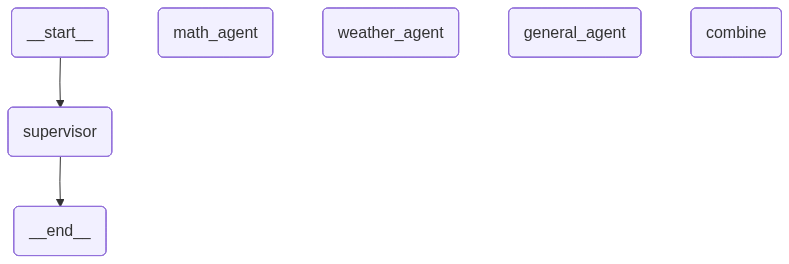

In [16]:
# ── Graph ─────────────────────────────────────────────────
builder = StateGraph(AgentState)

builder.add_node("supervisor",    supervisor)
builder.add_node("math_agent",    math_node)
builder.add_node("weather_agent", weather_node)
builder.add_node("general_agent", general_node)
builder.add_node("combine",       combine)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_to_agents)
builder.add_edge("math_agent",    "combine")
builder.add_edge("weather_agent", "combine")
builder.add_edge("general_agent", "combine")
builder.add_edge("combine", END)

graph = builder.compile()
graph

In [17]:
questions = [
    "What is 144 divided by 12?",
    "What is the weather in London?",
    "Who invented the telephone?",
    "What is the weather in Dhaka and what is 32 multiplied by 2?",
]

for q in questions:
    print(f"\n{'='*50}")
    print(f"Q: {q}")
    res = graph.invoke({"question": q, "agents": [], "answer": []})
    print(f"Final Answer:\n{res['answer'][-1]}")


Q: What is 144 divided by 12?
Final Answer:
{"name": "calculator", "arguments": {"first_num": 144, "operation": "div", "second_num": 12}}

Q: What is the weather in London?
Final Answer:
{"name": "get_weather", "arguments": {"city": "London"}}

Q: Who invented the telephone?
Final Answer:
The telephone was invented by Alexander Graham Bell in 1876.

Q: What is the weather in Dhaka and what is 32 multiplied by 2?
Final Answer:
{
  "name": "get_weather",
  "arguments": {
    "city": "Dhaka"
  }
}
{
  "name": "calculator",
  "arguments": {
    "first_num": 32,
    "operation": "mul",
    "second_num": 2
  }
}
